In [1]:
import dctkit as dt_
from dctkit import config
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from dctkit.mesh.simplex import SimplicialComplex
from dctkit.mesh import util
from dctkit.dec import cochain as C
from dctkit.dec.flat import flat_DPD as flat_par
from dctkit.dec.flat import flat_dual_upw as flat_upw
from matplotlib import cm
import pygmo as pg
import math
from jax import jit,lax
import time
import jax.numpy as jnp
from functools import partial
# import gmsh
# gmsh.initialize()

In [2]:
config()

In [3]:
# SPACE PARAMS
# spatial resolution
dx = 2**4/2**9
L = 2**4 + dx
#  Number of spatial grid points
nx = int(math.ceil(L / dx))
print(nx)

# vector containing spatial points
x = np.linspace(-L/2, L/2, nx)
# circumcenters
x_circ = (x[:-1] + x[1:])/2


# initial velocity
u_0 = np.exp(-1 * (x_circ + 0.5 * L/4)**2)
umax = np.max(u_0)
x_max = np.argmax(u_0)
print(x_circ[x_max])
print(umax)

513
-2.019561767578125
0.9997549348027434


In [56]:
# TIME PARAMS
T = 10
# temporal resolution
dt = 10/2**11
# number of temporal grid points
nt = int(math.ceil(T / dt))
print(nt)

# vector containing time points
t = np.linspace(0, T, nt)  

#Viscosity
nu = 0.005

nodes_BC = {'left': np.zeros(nt),
            'right': np.zeros(nt)}

2048


In [57]:
def main_run_FDM(u,x, dt, dx, nu, max_time_iter):
    for t in range(max_time_iter):
        u[1:-1, t+1] = u[1:-1, t] + dt * (nu * (u[2:, t] - 2 * u[1:-1, t] + u[:-2, t]) / dx**2 
                   - 0.25 * (u[2:, t]**2 - u[:-2, t]**2) / dx)
        #diffusion = epsilon * (u[2:, t] - 2 * u[1:-1, t] + u[:-2, t]) / dx**2
        #flux = (u[2:, t]**2 - u[:-2, t]**2) /(4*dx)
        #u[1:-1, t+1] = 1/2*(u[2:, t] + u[:-2, t]) + dt * (diffusion - flux)
        #print(np.linalg.norm(u[:,t+1]))
    return u

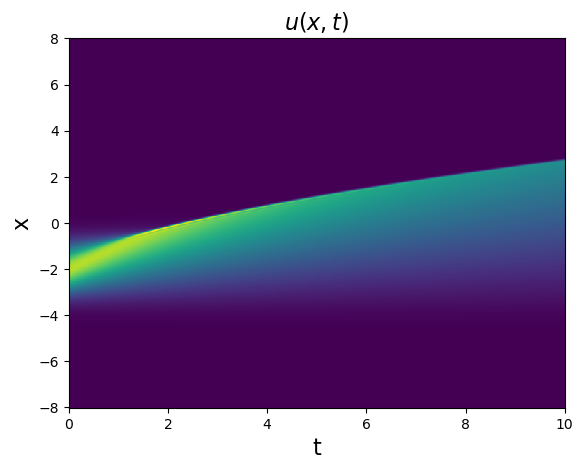

In [58]:
# Array containing velocity
u = np.zeros([nx-1, nt]) 

# Initial condition
u[:, 0] = u_0
# Boundary condition at x=0
u[0, :] = 0
# Boundary condition at x=xmax
u[-1, :] = 0 

u = main_run_FDM(u, x,dt, dx, nu, nt-1)


plt.pcolormesh(t,x_circ,u)
plt.xlabel('t', fontsize=16)
plt.ylabel('x', fontsize=16)
plt.title(r'$u(x, t)$', fontsize=16)
plt.show()

In [59]:
# define simplicial complex
mesh, _ = util.generate_line_mesh(nx, L, x_min=-L/2)
S = util.build_complex_from_mesh(mesh, space_dim=1)
S.get_hodge_star()
S.get_flat_DPD_weights()
S.get_flat_dual_upw_weights()

In [61]:
def compute_time_balance(u_t, nu, scheme: str = "parabolic"):
        u_coch = C.CochainD0(S, u_t)
        dissipation = C.scalar_mul(C.star(C.coboundary(u_coch)), nu)
        if scheme == "upwind":
            flat_u = flat_upw(u_coch)
            flux = C.scalar_mul(C.square(C.star(flat_u)), -1/2)
        elif scheme == "parabolic":
            u_sq = C.scalar_mul(C.square(u_coch), -1/2)
            flux = C.star(flat_par(u_sq))
        total_flux = C.add(flux, dissipation)
        balance = C.star(C.coboundary(total_flux))
        return balance


def run(u_0, nodes_BC, num_t_points, nu, step, scheme: str = "parabolic"):
        """Main run to solve Burgers' equation with DEC.

        Args:
            scheme: discretization scheme used.
        """
        u = np.zeros((S.num_nodes - 1, num_t_points//step),
                          dtype=dt_.float_dtype)
        # set initial and boundary conditions
        u[:, 0] = u_0
        u[0, :] = nodes_BC['left'][::step]
        u[-1, :] = nodes_BC['right'][::step]
        for t in range(num_t_points//step - 1):
            u_t = u[:, t]
            balance = compute_time_balance(u_t, nu, scheme)
            u[1:-1, t+1] = u[1:-1, t] + step*dt*balance.coeffs[1:-1].flatten()
        return u

In [65]:
u_dec = run(u_0, nodes_BC, nt, nu, 4, "upwind")

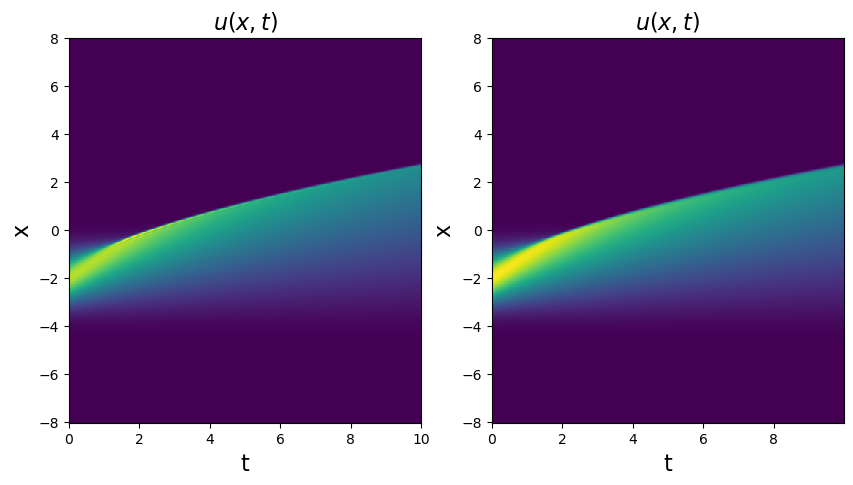

In [66]:
# FDM vs DEC
fig1, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pcolormesh(t, x_circ, u)
ax[1].pcolormesh(t[::4],x_circ,u_dec)
ax[0].set_xlabel('t', fontsize=16)
ax[0].set_ylabel('x', fontsize=16)
ax[0].set_title(r'$u(x, t)$', fontsize=16)
ax[1].set_xlabel('t', fontsize=16)
ax[1].set_ylabel('x', fontsize=16)
ax[1].set_title(r'$u(x, t)$', fontsize=16)
plt.show()

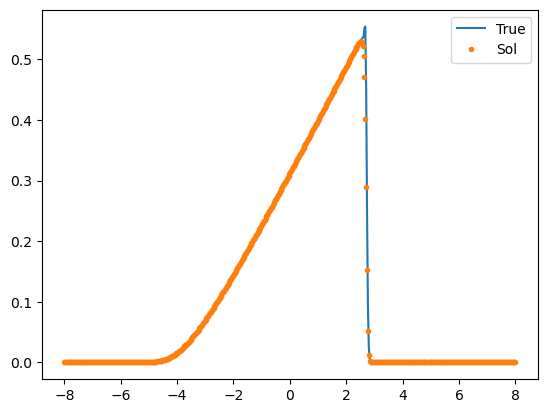

In [69]:
plt.plot(x_circ, u[:,-1], label="True")
plt.plot(x_circ, u_dec[:,-1], marker = ".", linewidth = 0.01, label="Sol")
plt.legend()
plt.show()